In [43]:
import pandas as pd  
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import metrics
from sklearn.metrics import roc_curve, auc

In [16]:
purchase_data1 = pd.read_csv('Purchase Data 1.csv')
purchase_data2 = pd.read_csv('Purchase Data 2.csv')
response_data = pd.read_csv('Response Data.csv')
masterdata=pd.merge(response_data,purchase_data1,how='left')
masterdata=pd.merge(masterdata,purchase_data2,how='left')

In [17]:
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [13]:
masterdata.dtypes

Custid           int64
Age           category
Gender        category
MS            category
Response         int64
Pre_Month     category
N_Products       int64
N_Service        int64
BillAmt_1      float64
BillAmt_2      float64
BillAmt_3      float64
dtype: object

In [12]:
masterdata['Age'] = masterdata['Age'].astype('category')
masterdata['Gender'] = masterdata['Gender'].astype('category')
masterdata['MS'] = masterdata['MS'].astype('category')
masterdata['Pre_Month'] = masterdata['Pre_Month'].astype('category')

In [14]:
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [18]:
masterdata.dtypes

Custid          int64
Age             int64
Gender          int64
MS              int64
Response        int64
Pre_Month       int64
N_Products      int64
N_Service       int64
BillAmt_1     float64
BillAmt_2     float64
BillAmt_3     float64
dtype: object

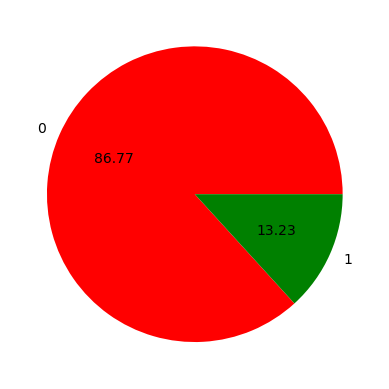

In [29]:
response = masterdata['Response'].value_counts().reset_index()
response.columns = ['Response', 'Count'] 

# Pie chart
y = np.array(response['Count'])
mylabels = response['Response']
plt.pie(y, labels=mylabels, autopct='%.2f', colors=['red','green'])
plt.show()


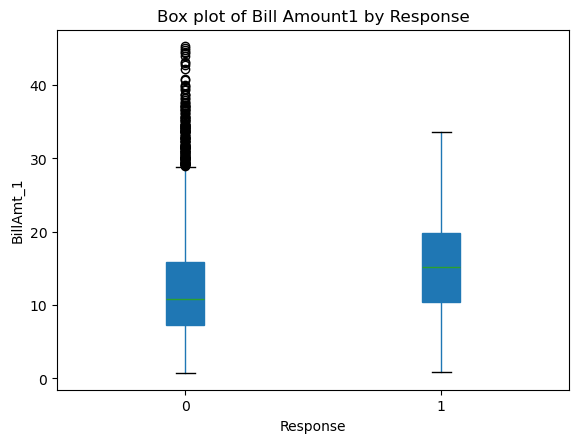

In [30]:
masterdata.boxplot(column='BillAmt_1', by='Response', grid=False, patch_artist=True);plt.title('Box plot of Bill Amount1 by Response');plt.suptitle('');plt.ylabel('BillAmt_1')
plt.show();

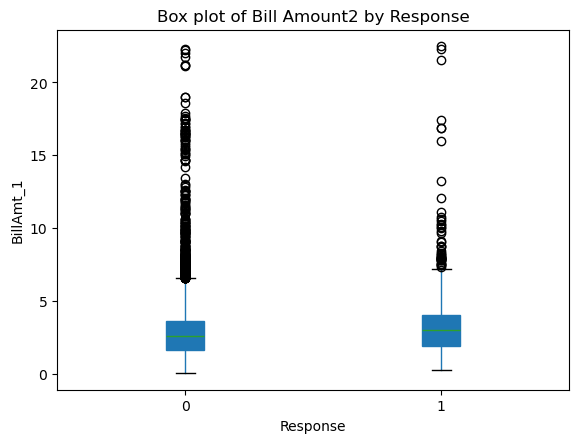

In [31]:
masterdata.boxplot(column='BillAmt_2', by='Response', grid=False, patch_artist=True);plt.title('Box plot of Bill Amount2 by Response');plt.suptitle('');plt.ylabel('BillAmt_1')
plt.show();

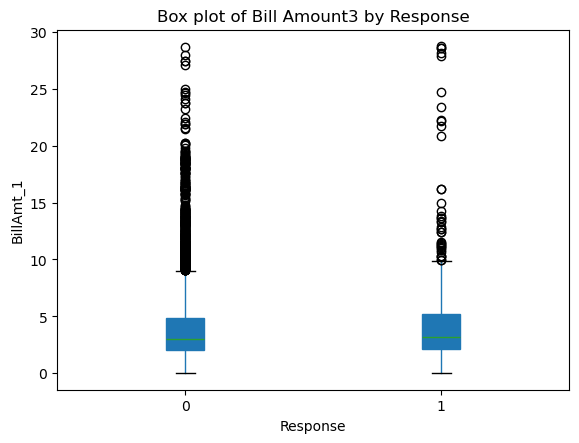

In [32]:
masterdata.boxplot(column='BillAmt_3', by='Response', grid=False, patch_artist=True);plt.title('Box plot of Bill Amount3 by Response');plt.suptitle('');plt.ylabel('BillAmt_1')
plt.show();

In [37]:
X = pd.DataFrame(masterdata.drop(columns=['Response','Custid']))
Y = masterdata['Response']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=5)

In [39]:
logreg = LogisticRegression(max_iter=200)

logreg.fit(X_train,Y_train)

LogisticRegression(max_iter=200)

In [40]:
logreg.coef_

array([[-0.04472449,  0.08779029, -0.16138082,  0.03857683,  0.14572965,
         0.0363677 ,  0.035094  ,  0.17537854,  0.01359982]])

In [42]:
y1, X1 = dmatrices('Response~Age+Gender+MS+Pre_Month+N_Products+N_Service+BillAmt_1+BillAmt_2+BillAmt_3', data=masterdata, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept     69.706018
Age            1.000538
Gender         1.001523
MS             1.001032
Pre_Month      1.001381
N_Products     1.507599
N_Service      1.138520
BillAmt_1      1.792992
BillAmt_2      1.687034
BillAmt_3      2.111605
dtype: float64

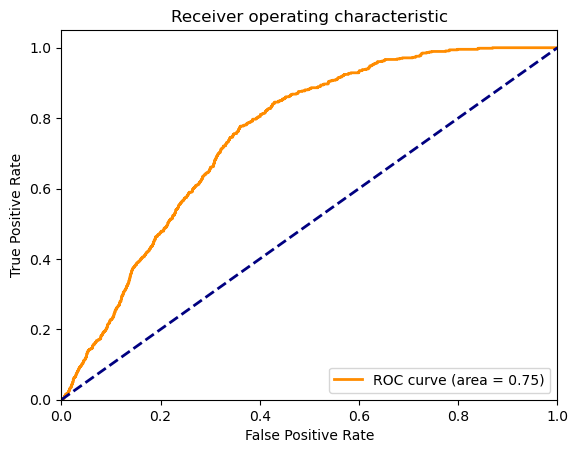

In [45]:
y_pred_probtrain = logreg.predict_proba(X_train)[::,1]
fpr, tpr, thresholds =roc_curve(Y_train,y_pred_probtrain)
roc_auc = auc(fpr, tpr)

ruc_auc = auc(fpr,tpr)

plt.figure();
lw = 2
plt.plot(fpr, tpr, color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' % ruc_auc);
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--');
plt.xlim([0.0, 1.0]);plt.ylim([0.0, 1.05]);
plt.xlabel('False Positive Rate');plt.ylabel('True Positive Rate');
plt.title('Receiver operating characteristic');plt.legend(loc="lower right");
plt.show()

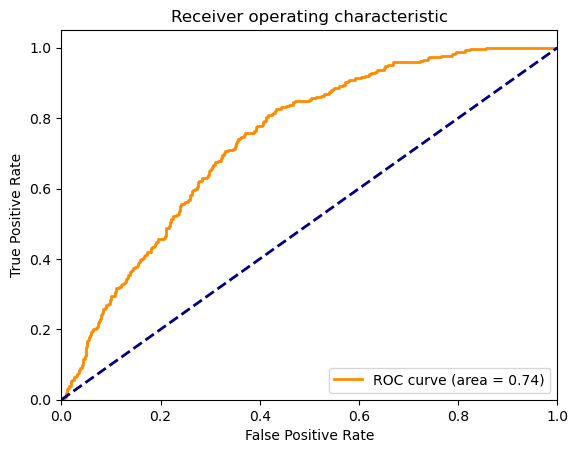

In [46]:
y_pred_probtest = logreg.predict_proba(X_test)[::,1]
fpr, tpr, thresholds =roc_curve(Y_test,y_pred_probtest)
roc_auc = auc(fpr, tpr)

ruc_auc = auc(fpr,tpr)

plt.figure();
lw = 2
plt.plot(fpr, tpr, color='darkorange',lw=lw, label='ROC curve (area = %0.2f)' % ruc_auc);
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--');
plt.xlim([0.0, 1.0]);plt.ylim([0.0, 1.05]);
plt.xlabel('False Positive Rate');plt.ylabel('True Positive Rate');
plt.title('Receiver operating characteristic');plt.legend(loc="lower right");
plt.show()

In [47]:
fpr, tpr, thresholds =roc_curve(Y_train,y_pred_probtrain)
roc_auc = auc(fpr, tpr)

i = np.arange(len(tpr)) 
roc = pd.DataFrame({'fpr' : pd.Series(fpr, index=i),'tpr' : pd.Series(tpr, index = i), '1-fpr' : pd.Series(1-fpr, index = i), 'tf' : pd.Series(tpr - (1-fpr), index = i), 'thresholds' : pd.Series(thresholds, index = i)})

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc.iloc[optimal_idx][4]
optimal_threshold

C:\Users\aykta\AppData\Local\Temp\ipykernel_34380\3690359822.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  optimal_threshold = roc.iloc[optimal_idx][4]


0.13467421611818187

In [48]:
predicted_values1=logreg.predict_proba(X_train)[::,1]
threshold=optimal_threshold
predicted_class1=np.zeros(predicted_values1.shape)
predicted_class1[predicted_values1>threshold]=1

from sklearn.metrics import classification_report
print(classification_report(Y_train,predicted_class1))

              precision    recall  f1-score   support

           0       0.95      0.64      0.76      4233
           1       0.25      0.78      0.38       660

    accuracy                           0.66      4893
   macro avg       0.60      0.71      0.57      4893
weighted avg       0.85      0.66      0.71      4893



In [49]:
predicted_values1=logreg.predict_proba(X_test)[::,1]
threshold=optimal_threshold
predicted_class1=np.zeros(predicted_values1.shape)
predicted_class1[predicted_values1>threshold]=1

print(classification_report(Y_test,predicted_class1))

              precision    recall  f1-score   support

           0       0.95      0.63      0.75      1832
           1       0.23      0.76      0.35       265

    accuracy                           0.64      2097
   macro avg       0.59      0.69      0.55      2097
weighted avg       0.86      0.64      0.70      2097



In [51]:
#K-fold cross validation
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import cohen_kappa_score

predicted_prob = cross_val_predict(logreg, X, Y, cv=4, method='predict_proba') 
threshold=optimal_threshold
predicted = predicted_prob[:,1]
predicted_class1=np.zeros(predicted.shape)
predicted_class1[predicted>threshold]=1

print(classification_report(Y,predicted_class1))

              precision    recall  f1-score   support

           0       0.94      0.64      0.77      6065
           1       0.24      0.75      0.37       925

    accuracy                           0.66      6990
   macro avg       0.59      0.70      0.57      6990
weighted avg       0.85      0.66      0.71      6990

